In [1]:
import pandas as pd 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.utils import resample
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
#%matplotlib inline
from math import sqrt
#from statsmodels.tsa.arima_model import ARIMA
from sklearn.metrics import mean_squared_error

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')
pd.set_option('display.max_column',None)

In [3]:
df = pd.read_csv('Super_Store_ts.csv', encoding= 'latin1') #2121; 21 , 1st is RowID 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   RowID          2121 non-null   int64  
 1   OrderID        2121 non-null   object 
 2   OrderDate      2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   ShipMode       2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  PostalCode     2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  ProductID      2121 non-null   object 
 14  Category       2121 non-null   object 
 15  SubCategory    2121 non-null   object 
 16  ProductName    2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

In [4]:
#Changing the datatype being its a date
df['Order_Date'] = pd.to_datetime(df['OrderDate'])
df['Order_year'] = pd.DatetimeIndex(df['OrderDate']).year
df['Order_month'] = pd.DatetimeIndex(df['OrderDate']).month
df.info()
df.shape #2121, 24
df.Order_Date.head()
df.Order_Date.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   RowID          2121 non-null   int64         
 1   OrderID        2121 non-null   object        
 2   OrderDate      2121 non-null   object        
 3   Ship Date      2121 non-null   object        
 4   ShipMode       2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  PostalCode     2121 non-null   int64         
 12  Region         2121 non-null   object        
 13  ProductID      2121 non-null   object        
 14  Category       2121 non-null   object        
 15  SubCategory    2121 n

count                    2121
unique                    889
top       2016-09-05 00:00:00
freq                       10
first     2014-01-06 00:00:00
last      2017-12-30 00:00:00
Name: Order_Date, dtype: object

(array([16071., 16252., 16436., 16617., 16801., 16983., 17167., 17348.,
        17532.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

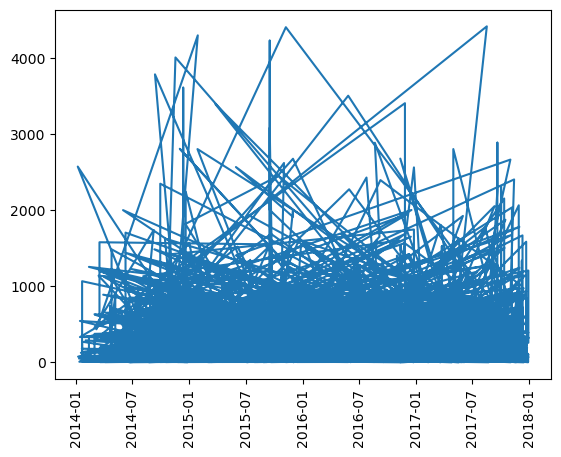

In [5]:
# sales vs Order_Date [after index, not work! ]
plt.plot(df.Order_Date, df.Sales) # difficult to interpret!
plt.xticks(rotation=90)

In [8]:
# order date vs ship date
df.info()
df.ShipDate = pd.to_datetime(df.Ship Date) #not worked!


SyntaxError: invalid syntax (2374588183.py, line 3)

In [9]:
# rename Ship Date to ShipDate
df = df.rename(columns = {'Ship Date': 'ShipDate'})
df.ShipDate = pd.to_datetime(df.ShipDate) # worked!haha
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   RowID          2121 non-null   int64         
 1   OrderID        2121 non-null   object        
 2   OrderDate      2121 non-null   object        
 3   ShipDate       2121 non-null   datetime64[ns]
 4   ShipMode       2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  PostalCode     2121 non-null   int64         
 12  Region         2121 non-null   object        
 13  ProductID      2121 non-null   object        
 14  Category       2121 non-null   object        
 15  SubCategory    2121 n

In [10]:
df.ShipDate.describe()

count                    2121
unique                    960
top       2017-12-06 00:00:00
freq                       10
first     2014-01-10 00:00:00
last      2018-01-05 00:00:00
Name: ShipDate, dtype: object

In [11]:
# nos of days in delivery?
df['DaysInDelivery'] = df['ShipDate'].sub(df['Order_Date'], axis=0)
df['DaysInDelivery'].head() 

0   3 days
1   3 days
2   7 days
3   5 days
4   5 days
Name: DaysInDelivery, dtype: timedelta64[ns]

In [12]:
df.DaysInDelivery.describe()


count                         2121
mean     3 days 22:00:30.551626591
std      1 days 18:07:32.231661933
min                0 days 00:00:00
25%                3 days 00:00:00
50%                4 days 00:00:00
75%                5 days 00:00:00
max                7 days 00:00:00
Name: DaysInDelivery, dtype: object

In [13]:
#Indexing data with Order_Date
df = df.set_index('Order_Date')
df.head()


,RowID,OrderID,OrderDate,ShipDate,ShipMode,Customer ID,Customer Name,Segment,Country,City,State,PostalCode,Region,ProductID,Category,SubCategory,ProductName,Sales,Quantity,Discount,Profit,Order_year,Order_month,DaysInDelivery
Order_Date,,,,,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,11-08-2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,3 days
2016-11-08,2,CA-2016-152156,11-08-2016,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,3 days
2015-10-11,4,US-2015-108966,10-11-2015,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,7 days
2014-06-09,6,CA-2014-115812,06-09-2014,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014,6,5 days
2014-06-09,11,CA-2014-115812,06-09-2014,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092,2014,6,5 days


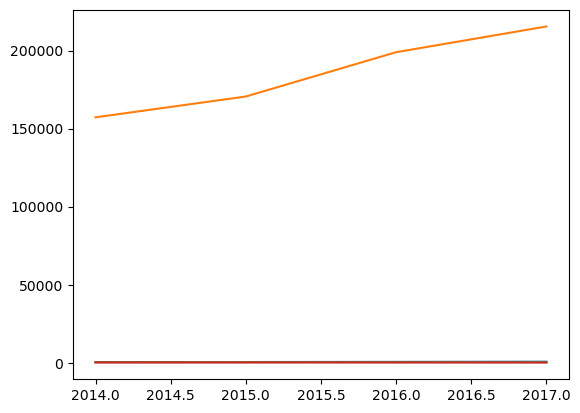

In [14]:
# year wise
plt.plot(df.groupby('Order_year')['Sales'].count())
plt.plot(df.groupby('Order_year')['Sales'].sum())
plt.plot(df.groupby('Order_year')['Sales'].mean())
plt.plot(df.groupby('Order_year')['Sales'].median())

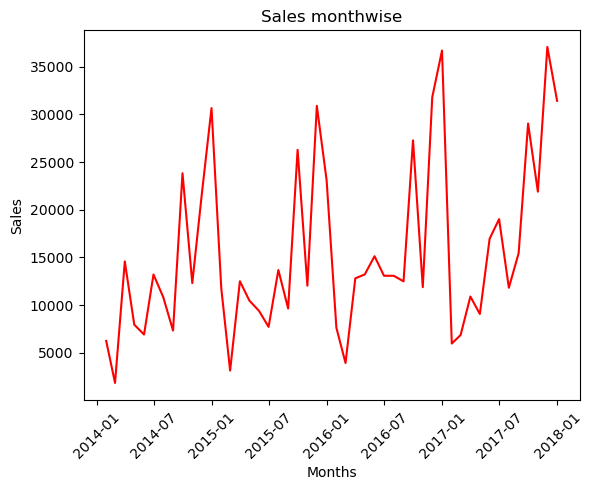

In [15]:
#___________let's see monthwise sales in different way!
#Resample helps to filter data sec, min, hour, day, week, month, year wise 
#Resample works only when index is in date format..
plt.plot(df.Sales.resample('M').sum(), 'r')
plt.xticks(rotation=45)
plt.title('Sales monthwise')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.show()


In [16]:

#@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
#1 Sales
df.Sales.describe()

count    2121.000000
mean      349.834887
std       503.179145
min         1.892000
25%        47.040000
50%       182.220000
75%       435.168000
max      4416.174000
Name: Sales, dtype: float64

<AxesSubplot:xlabel='Sales', ylabel='Density'>

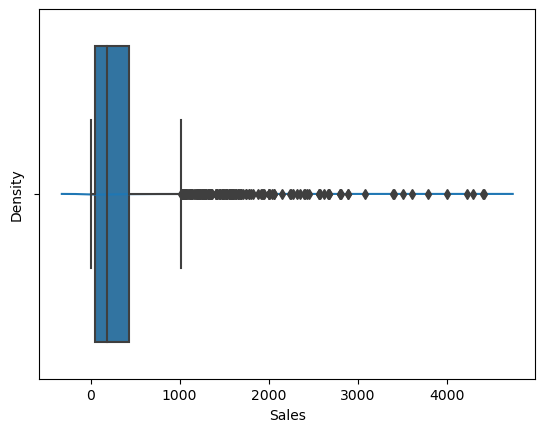

In [17]:
df.Sales.value_counts() #less useful here
sns.distplot(df.Sales) #good plot
sns.boxplot(df.Sales) # good insight 

In [18]:
#2 ShipMode

df.ShipMode.describe() #useful
df.ShipMode.value_counts()

Standard Class    1248
Second Class       427
First Class        327
Same Day           119
Name: ShipMode, dtype: int64

<AxesSubplot:xlabel='ShipMode', ylabel='count'>

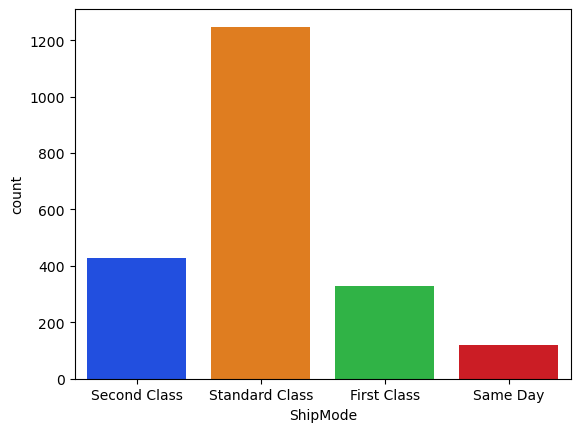

In [19]:
sns.countplot(df.ShipMode, palette = 'bright')


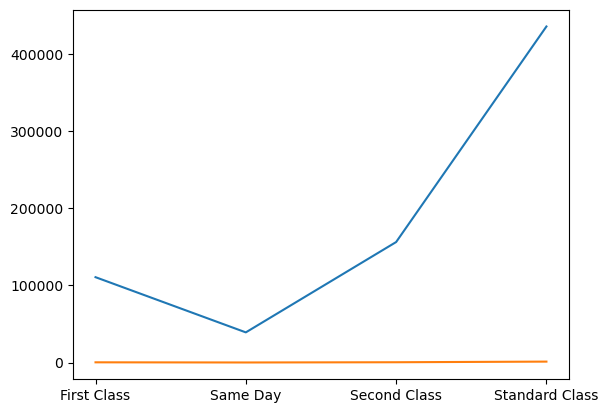

In [20]:
# Sum Sales by ShipMode 
plt.plot(df.groupby('ShipMode')['Sales'].sum())
plt.plot(df.groupby('ShipMode')['Sales'].count())

In [21]:
#3 Customer Name
df.info()
df.Customer Name.unique().shape # not worked
df = df.rename(columns = {'Customer Name': 'CustomerName'})
df.CustomerName.unique().shape
df.CustomerName.unique() #too big list, haha!

SyntaxError: invalid syntax (2703223168.py, line 3)

In [22]:
df = df.rename(columns = {'Customer Name': 'CustomerName'})
df.CustomerName.unique().shape
df.CustomerName.unique() #too big list, haha!

array(['Claire Gute', "Sean O'Donnell", 'Brosina Hoffman',
       'Sandra Flanagan', 'Emily Burns', 'Tracy Blumstein', 'Gene Hale',
       'Steve Nguyen', 'Darren Powers', 'Ted Butterfield', 'Kunst Miller',
       'Paul Stevenson', 'Joel Eaton', 'Ken Brennan', "Patrick O'Donnell",
       'Karl Braun', 'Parhena Norris', 'Lena Cacioppo', 'Cynthia Voltz',
       'Dave Kipp', 'Steven Cartwright', 'Alan Dominguez', 'Philip Fox',
       'Lindsay Shagiari', 'Lena Creighton', 'Jonathan Doherty',
       'Maureen Gastineau', 'Justin Ellison', 'Dave Brooks',
       'Becky Martin', 'Chad Sievert', 'Mark Packer', 'Bruce Stewart',
       'Heather Kirkland', 'Victoria Wilson', 'Joni Blumstein',
       'David Smith', 'Valerie Dominguez', 'Christopher Schild',
       'Ken Lonsdale', 'Dianna Wilson', 'Logan Haushalter',
       'Dan Reichenbach', 'Helen Andreada', "Jas O'Carroll",
       'Nick Zandusky', 'Kelly Lampkin', 'Jonathan Howell',
       'Alan Schoenberger', 'Ben Peterman', 'Thomas Seio', 'Natha

In [23]:

# RowId, OrderID, Customer ID, Postal Codes,
# ProductID, Quantity, Discount, Profit; seem to be less
# important for time series analysis

In [25]:
#4 segment 
df.info()
df.Segment.describe() # useful
df.Segment.value_counts()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

Consumer       1113
Corporate       646
Home Office     362
Name: Segment, dtype: int64

<AxesSubplot:xlabel='Segment', ylabel='count'>

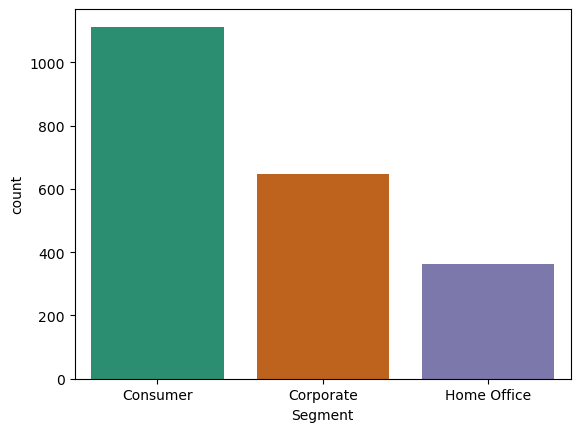

In [26]:
sns.countplot(df.Segment, palette = 'Dark2')


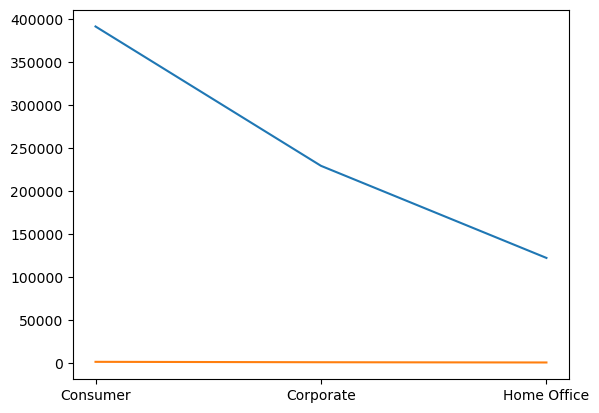

In [27]:
# Sum Sales by Segment
plt.plot(df.groupby('Segment')['Sales'].sum())
plt.plot(df.groupby('Segment')['Sales'].count())


In [28]:
#5 Country
df.info()
df.Country.describe() #not so useful, only 1 country
df.Country.value_counts()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

United States    2121
Name: Country, dtype: int64

<AxesSubplot:xlabel='Country', ylabel='count'>

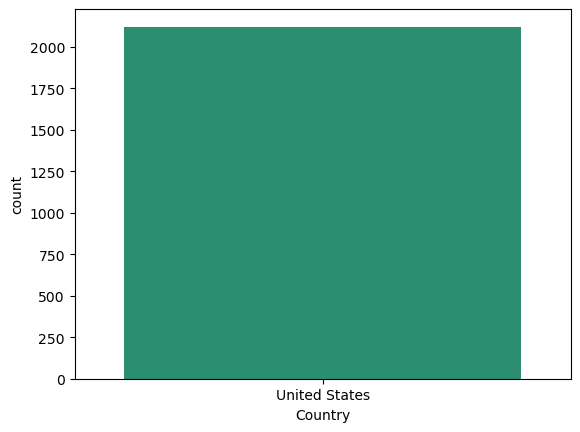

In [29]:
sns.countplot(df.Country, palette = 'Dark2')


In [30]:
#6 city
df.info()
df.City.describe() #useful

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

count              2121
unique              371
top       New York City
freq                192
Name: City, dtype: object

In [31]:
df.City.value_counts()

New York City     192
Los Angeles       154
Philadelphia      111
San Francisco     102
Seattle            97
                 ... 
Tyler               1
Port Arthur         1
Citrus Heights      1
Bullhead City       1
Indianapolis        1
Name: City, Length: 371, dtype: int64

<AxesSubplot:xlabel='City', ylabel='count'>

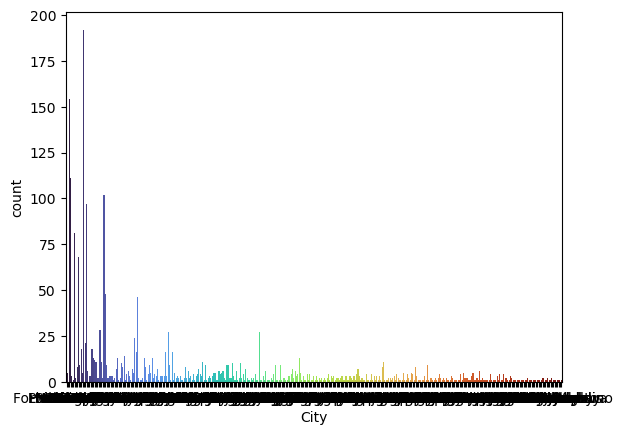

In [32]:
sns.countplot(x = df.City, palette = 'turbo')


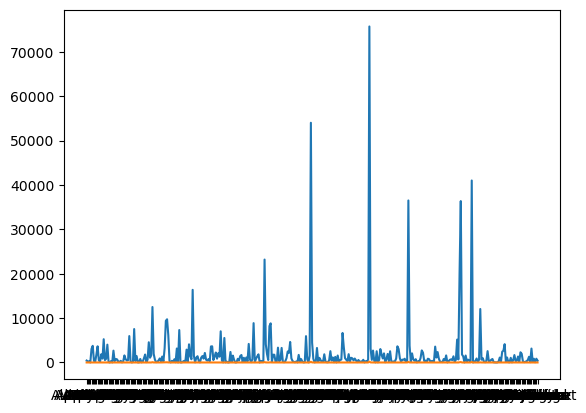

In [33]:
# sum Sales by City
plt.plot(df.groupby('City')['Sales'].sum())
plt.plot(df.groupby('City')['Sales'].count())

In [34]:
citysales = df.groupby('City')['Sales'].sum()
citysales.head()
#take this [citysales] to desktop 
# from variable explorer
# or, export through code

City
Akron          433.5960
Alexandria     267.4600
Allen          244.0060
Allentown       11.6480
Amarillo      3048.5828
Name: Sales, dtype: float64

In [35]:
cs = pd.DataFrame(citysales)
cs.to_csv('cs.csv')

In [36]:
#7 State
df.info()
df.State.describe() #useful
df.State.value_counts()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

California              444
New York                236
Texas                   202
Pennsylvania            125
Illinois                123
Washington              114
Ohio                     93
Florida                  85
Virginia                 52
Colorado                 51
Michigan                 50
Arizona                  49
Tennessee                45
North Carolina           42
Massachusetts            33
Georgia                  32
Wisconsin                32
Kentucky                 30
Maryland                 28
New Jersey               26
Indiana                  23
Oregon                   21
Delaware                 18
Rhode Island             16
Oklahoma                 15
Minnesota                13
Connecticut              13
Louisiana                11
Alabama                  11
Missouri                 11
Mississippi               9
Arkansas                  9
Nevada                    9
Utah                      7
New Hampshire             6
South Carolina      

<AxesSubplot:xlabel='State', ylabel='count'>

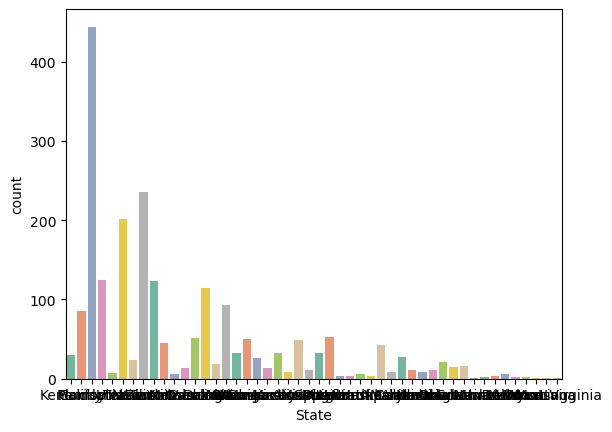

In [37]:
sns.countplot(x = df.State, palette = 'Set2')


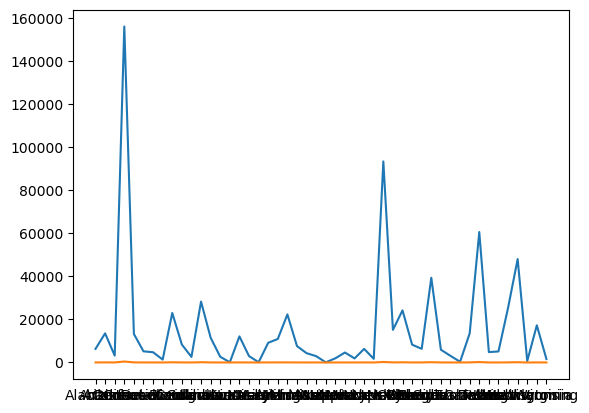

In [38]:
# sum Sales by state
plt.plot(df.groupby('State')['Sales'].sum())
plt.plot(df.groupby('State')['Sales'].count())

In [39]:
statesales = df.groupby('State')['Sales'].sum()
statesales.head()
#take this [statesales] to desktop 
# from variable explorer
# or, export through code

State
Alabama         6332.4800
Arizona        13525.2910
Arkansas        3187.5500
California    156064.6015
Colorado       13243.0370
Name: Sales, dtype: float64

In [40]:
ss = pd.DataFrame(statesales)
ss.to_csv('ss.csv')

In [41]:
#8 Region
df.info()
df.Region.describe() #useful
df.Region.value_counts()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

West       707
East       601
Central    481
South      332
Name: Region, dtype: int64

<AxesSubplot:xlabel='Region', ylabel='count'>

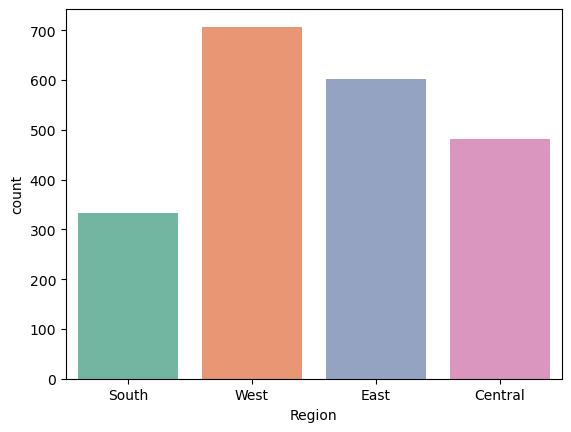

In [42]:
sns.countplot(x = df.Region, palette = 'Set2')


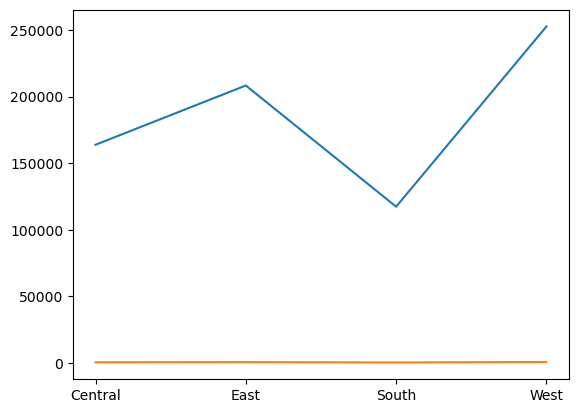

In [43]:
# sum Sales by Region
plt.plot(df.groupby('Region')['Sales'].sum())
plt.plot(df.groupby('Region')['Sales'].count())

In [44]:
regionsales = df.groupby('Region')['Sales'].sum()
regionsales.head()
#take this [regionsales] to desktop 
# from variable explorer
# or, export through code

Region
Central    163797.1638
East       208291.2040
South      117298.6840
West       252612.7435
Name: Sales, dtype: float64

In [45]:
rs = pd.DataFrame(regionsales)
rs.to_csv('rs.csv')


In [46]:
#9 Category
df.info()
df.Category.describe() #NOT useful
df.Category.value_counts()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

Furniture    2121
Name: Category, dtype: int64

In [47]:
#10 SubCategory
df.info()
df.SubCategory.describe() #useful
df.SubCategory.value_counts()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

Furnishings    957
Chairs         617
Tables         319
Bookcases      228
Name: SubCategory, dtype: int64

<AxesSubplot:xlabel='SubCategory', ylabel='count'>

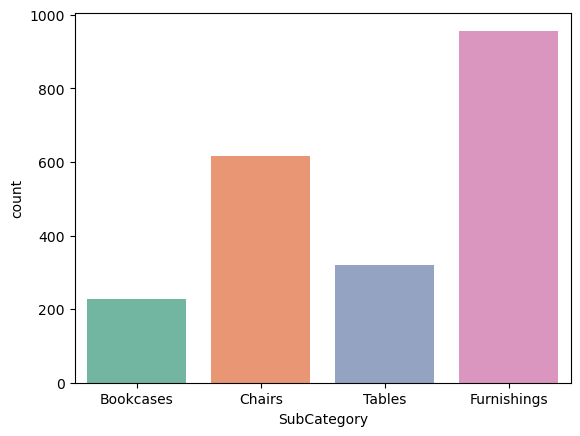

In [48]:
sns.countplot(x = df.SubCategory, palette = 'Set2')

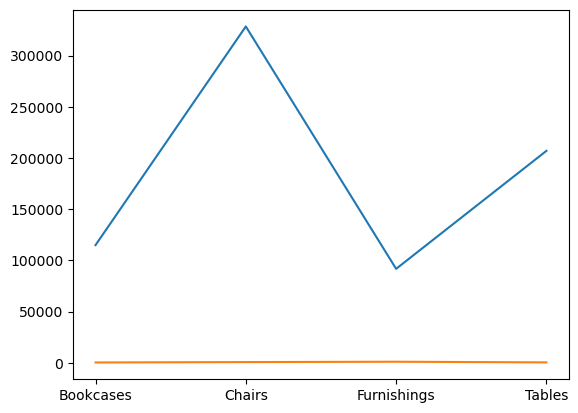

In [49]:
# sum Sales by SubCategory
plt.plot(df.groupby('SubCategory')['Sales'].sum())
plt.plot(df.groupby('SubCategory')['Sales'].count())

In [50]:
#11 ProductName
df.info()
df.ProductName.describe() #useful
df.ProductName.value_counts() #big list

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

KI Adjustable-Height Table                                                   18
Staple-based wall hangings                                                   16
Situations Contoured Folding Chairs, 4/Set                                   15
Eldon Wave Desk Accessories                                                  14
Global Wood Trimmed Manager's Task Chair, Khaki                              14
                                                                             ..
Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order     1
Barricks Non-Folding Utility Table with Steel Legs, Laminate Tops             1
Bush Westfield Collection Bookcases, Dark Cherry Finish, Fully Assembled      1
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs                  1
Ultra Commercial Grade Dual Valve Door Closer                                 1
Name: ProductName, Length: 380, dtype: int64

<AxesSubplot:xlabel='ProductName', ylabel='count'>

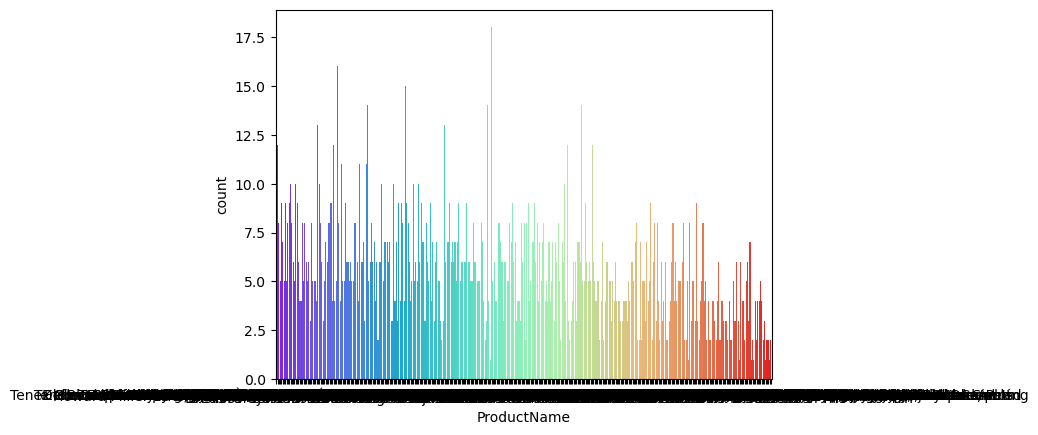

In [51]:
sns.countplot(x = df.ProductName, palette = 'rainbow') #lessuseful


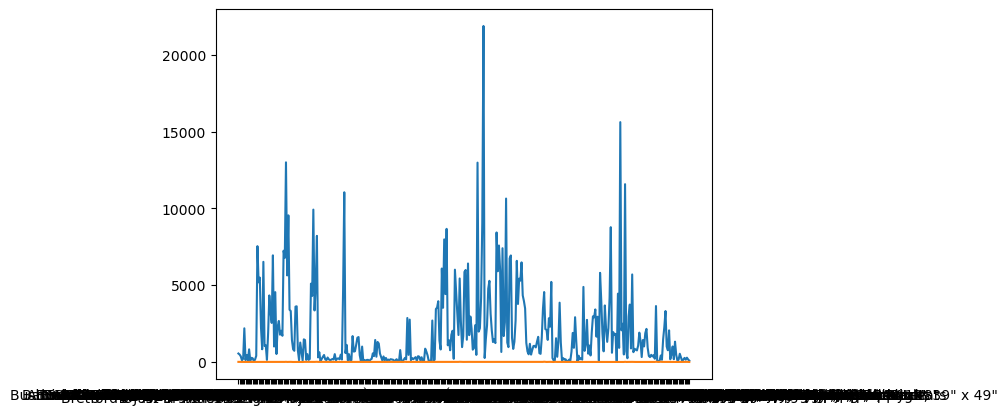

In [52]:
# sum Sales by ProductName
plt.plot(df.groupby('ProductName')['Sales'].sum())
plt.plot(df.groupby('ProductName')['Sales'].count())

In [53]:
psales = df.groupby('ProductName')['Sales'].sum()
psales.head()
#take this [psales] to desktop 
# from variable explorer
# or, export through code

ProductName
12-1/2 Diameter Round Wall Clock      551.448
24-Hour Round Wall Clock              487.512
36X48 HARDFLOOR CHAIRMAT              369.248
3M Hangers With Command Adhesive      108.040
3M Polarizing Light Filter Sleeves    216.340
Name: Sales, dtype: float64

In [54]:
ps = pd.DataFrame(psales)
ps.to_csv('ps.csv')

In [55]:
#12 Quantity 
df.info()
df.Quantity.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

count    2121.000000
mean        3.785007
std         2.251620
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        14.000000
Name: Quantity, dtype: float64

<AxesSubplot:xlabel='Quantity', ylabel='Density'>

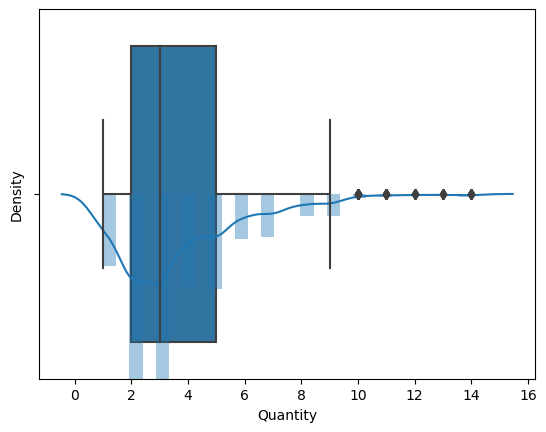

In [56]:
sns.distplot(x=df.Quantity)
sns.boxplot(x = df.Quantity)

In [57]:
#13 Discount 
df.info()
df.Discount.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

count    2121.000000
mean        0.173923
std         0.181547
min         0.000000
25%         0.000000
50%         0.200000
75%         0.300000
max         0.700000
Name: Discount, dtype: float64

<AxesSubplot:xlabel='Discount', ylabel='Density'>

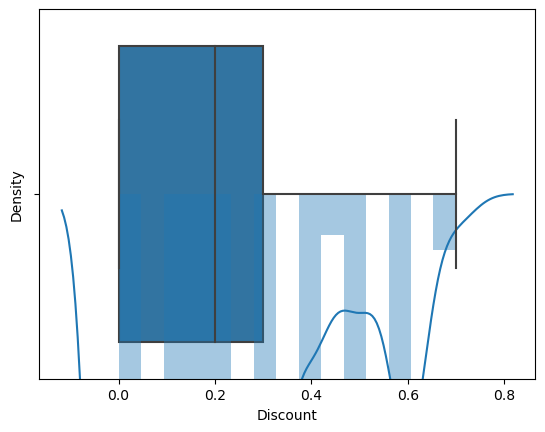

In [58]:
sns.distplot(x=df.Discount)
sns.boxplot(x = df.Discount)

In [59]:
#14 Profit
df.info()
df.Profit.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2121 entries, 2016-11-08 to 2017-02-26
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   RowID           2121 non-null   int64          
 1   OrderID         2121 non-null   object         
 2   OrderDate       2121 non-null   object         
 3   ShipDate        2121 non-null   datetime64[ns] 
 4   ShipMode        2121 non-null   object         
 5   Customer ID     2121 non-null   object         
 6   CustomerName    2121 non-null   object         
 7   Segment         2121 non-null   object         
 8   Country         2121 non-null   object         
 9   City            2121 non-null   object         
 10  State           2121 non-null   object         
 11  PostalCode      2121 non-null   int64          
 12  Region          2121 non-null   object         
 13  ProductID       2121 non-null   object         
 14  Category        2121 n

count    2121.000000
mean        8.699327
std       136.049246
min     -1862.312400
25%       -12.849000
50%         7.774800
75%        33.726600
max      1013.127000
Name: Profit, dtype: float64

<AxesSubplot:xlabel='Profit', ylabel='Density'>

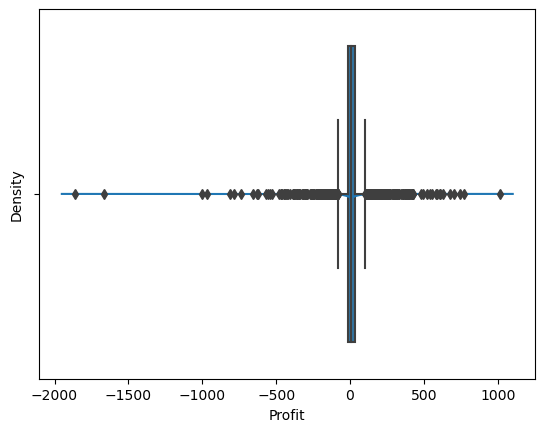

In [60]:
sns.distplot(x=df.Profit)
sns.boxplot(x = df.Profit)

In [61]:
#________eda over, lets export this file for modeling
df.to_csv('ssts.csv')